In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("used_cars.csv")

# Preview dataset
df.head()

,brand,model,model_year,mileage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


In [ ]:
# Dataset Overview

# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumns in Dataset:")
print(df.columns)

# Data types and missing values
print("\nDataset Info:")
df.info()

# Summary statistics for numerical features
print("\nSummary Statistics:")
df.describe()

Dataset Shape:
(3889, 12)

Columns in Dataset:
Index(['brand', 'model', 'model_year', 'mileage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3889 entries, 0 to 3888
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3889 non-null   object 
 1   model         3889 non-null   object 
 2   model_year    3889 non-null   int64  
 3   mileage       3889 non-null   int64  
 4   fuel_type     3719 non-null   object 
 5   engine        3889 non-null   object 
 6   transmission  3889 non-null   object 
 7   ext_col       3889 non-null   object 
 8   int_col       3889 non-null   object 
 9   accident      3783 non-null   object 
 10  clean_title   3334 non-null   object 
 11  price         3889 non-null   float64
dtypes: float64(1), int64(2), object(9)
memor

,model_year,mileage,price
count,3889.000000,3889.000000,3889.000000
mean,2015.397789,66446.612754,36292.783235
std,6.121238,52125.827380,26134.268222
min,1974.000000,100.000000,2000.000000
25%,2012.000000,25000.000000,16995.000000
50%,2017.000000,54900.000000,30000.000000
75%,2020.000000,95500.000000,47500.000000
max,2024.000000,405000.000000,149900.000000


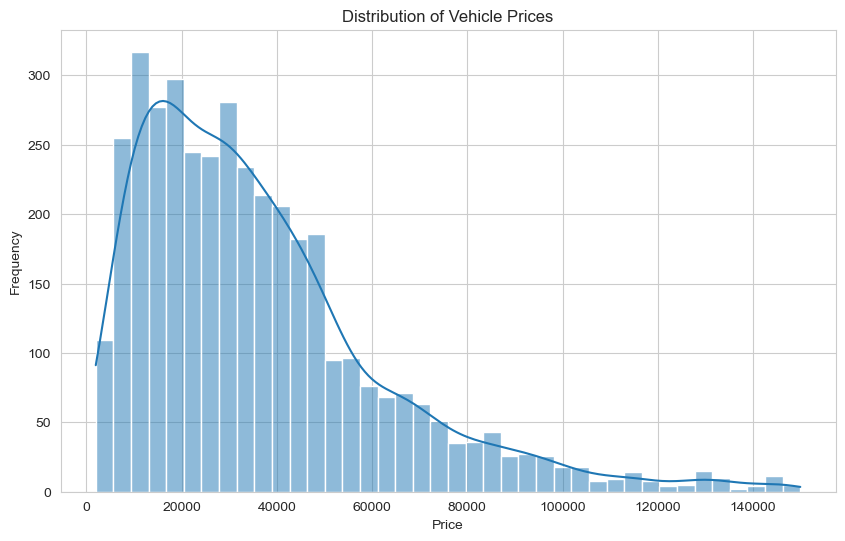

In [ ]:
# Target Feature Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Histogram of price
plt.figure(figsize=(10,6))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

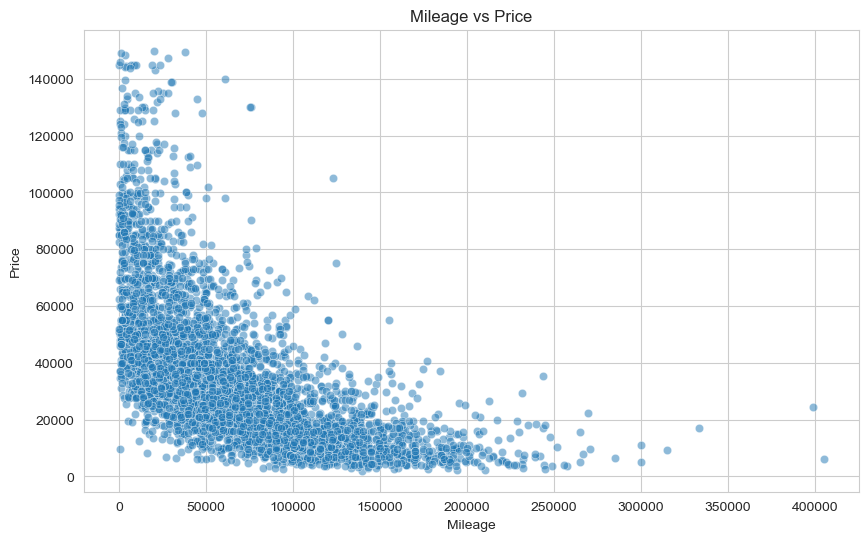

In [ ]:
# Mileage vs Price Relationship

plt.figure(figsize=(10,6))
sns.scatterplot(x="mileage", y="price", data=df, alpha=0.5)

plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

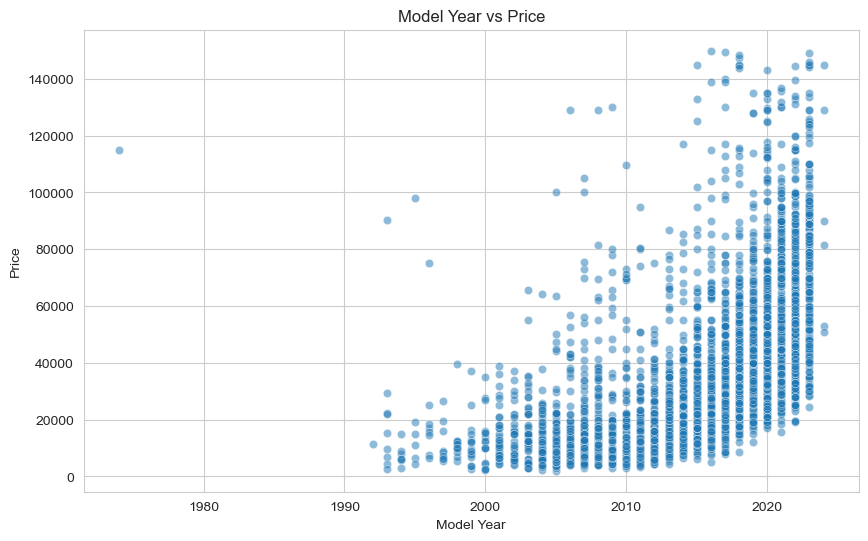

In [ ]:
#Model Year vs Price Relationship

plt.figure(figsize=(10,6))
sns.scatterplot(x="model_year", y="price", data=df, alpha=0.5)

plt.title("Model Year vs Price")
plt.xlabel("Model Year")
plt.ylabel("Price")
plt.show()

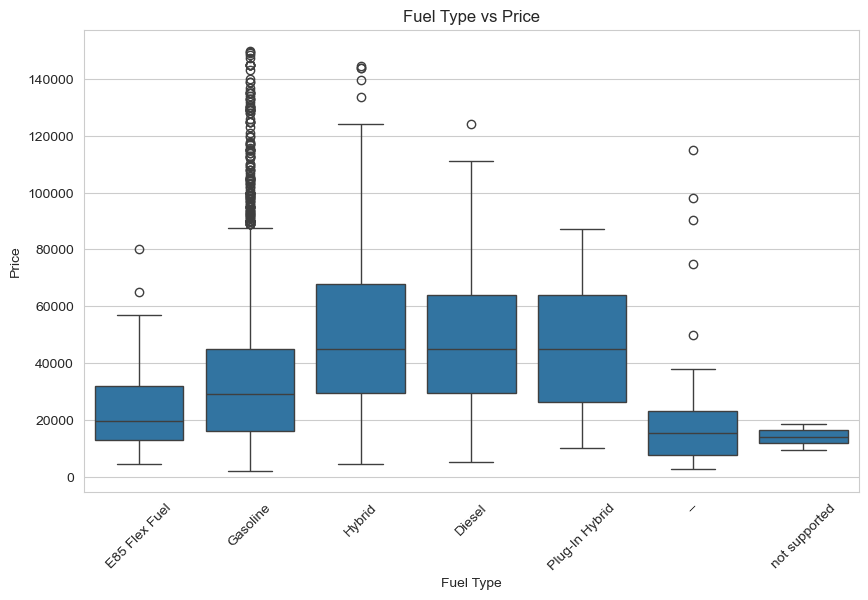

In [ ]:
# Fuel Type vs Price

plt.figure(figsize=(10,6))
sns.boxplot(x="fuel_type", y="price", data=df)

plt.title("Fuel Type vs Price")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

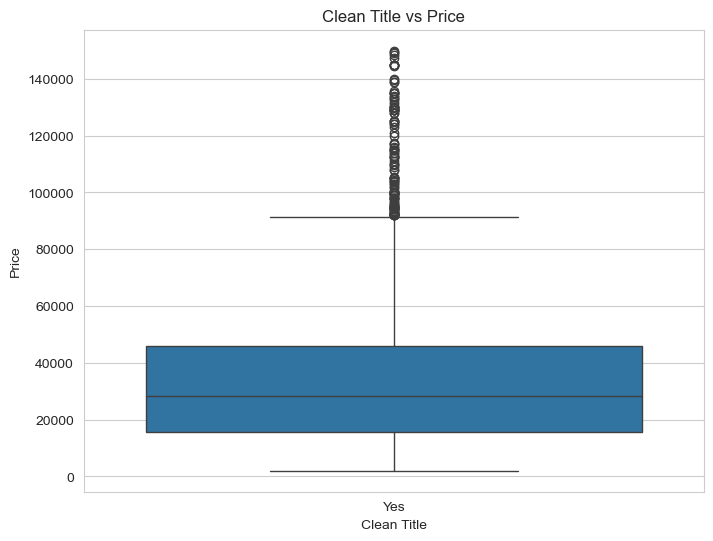

In [ ]:
# Clean Title vs Price

plt.figure(figsize=(8,6))
sns.boxplot(x="clean_title", y="price", data=df)

plt.title("Clean Title vs Price")
plt.xlabel("Clean Title")
plt.ylabel("Price")
plt.show()

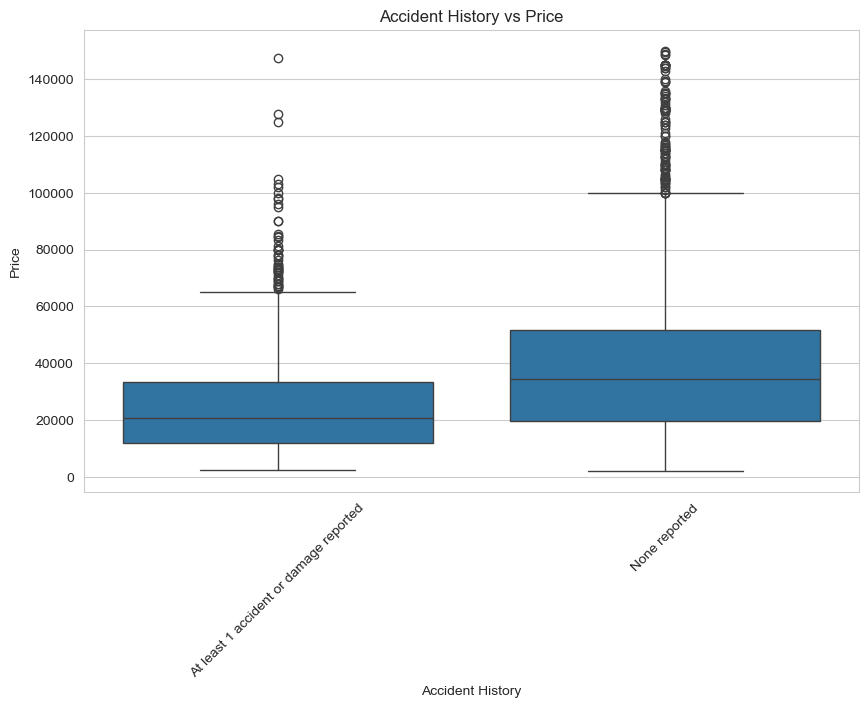

In [ ]:
# Accident History vs Price

plt.figure(figsize=(10,6))
sns.boxplot(x="accident", y="price", data=df)

plt.title("Accident History vs Price")
plt.xlabel("Accident History")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

After examining the distribution of vehicle prices, I noticed that the data is clearly right-skewed. Most vehicles fall between roughly $10,000 and $50,000, while fewer vehicles appear in the higher price ranges above $80,000. The histogram confirms that extremely high-priced vehicles are present but much less common. I found it interesting that the maximum price reaches $149,900, which explains the long tail in the distribution.

When reviewing the scatter plot of mileage versus price, I discovered a strong negative relationship. As mileage increases, vehicle price generally decreases. Vehicles with very low mileage often have significantly higher prices, while those above 150,000 miles tend to cluster at much lower price points. From what I observed, mileage appears to be one of the strongest predictors of price in this dataset.

The model year versus price visualization shows a clear positive relationship. Newer vehicles consistently display higher price values, especially models from 2015 and later. I noticed that vehicles from the early 2000s and 1990s are concentrated at lower price ranges, while more recent model years show a wider spread and higher pricing overall. This pattern strongly suggests that model year plays a major role in vehicle valuation.

Looking at fuel type versus price, I observed that hybrid and diesel vehicles tend to have higher median prices compared to standard gasoline vehicles. Gasoline vehicles show a wide range, including many high-priced outliers. I found that plug-in hybrids also maintain relatively strong price levels. E85 Flex Fuel vehicles appear to trend lower overall compared to hybrid and diesel categories.

For clean title versus price, the data only shows one visible category (“Yes”), indicating most vehicles have clean titles recorded. I noticed a wide range of prices within this group, including several high-priced outliers. While clean title status appears common, this variable alone does not seem to explain large pricing differences based on the chart shown.

Finally, when examining accident history versus price, I found a noticeable difference between vehicles with reported accidents and those with none reported. Vehicles with no reported accidents generally show higher median prices and a broader upper range. In contrast, vehicles with at least one accident or damage reported tend to cluster at lower price levels. This suggests accident history likely has a negative impact on vehicle value.

Overall, I concluded that mileage and model year demonstrate the strongest relationships with price. Fuel type and accident history also show meaningful patterns, while clean title status appears less informative based on the available visualization.

After completing this analysis, I feel confident that the dataset clearly demonstrates meaningful relationships between vehicle characteristics and price. The strongest patterns I identified were between mileage and price, as well as model year and price. Higher mileage consistently corresponded with lower prices, while newer vehicles showed higher pricing trends.

I also discovered that fuel type and accident history influence vehicle value. Hybrid and diesel vehicles generally showed higher median prices, while vehicles with reported accidents tended to sell for less compared to those with no reported damage. Although clean title status appeared consistent across most listings, it did not show a strong differentiating effect based on the visualization.

Overall, this analysis helped me better understand how multiple quantitative and categorical features contribute to vehicle pricing. The patterns observed in the charts support logical real-world expectations, which strengthens confidence in the dataset’s reliability.